## Estimacion con ARIMA

Vamos a estimar con un modelo ARIMA el pronostico de la actividad solar. Para esto, vamos a usar la base de datos sunspot de statsmodels.datasets.sunspots. Esta base de datos contiene la actividad solar medida en numero de manchas solares por año desde el año 1700 hasta el año 2008. 

La estimacion sera a 5 años a futuro, es decir, hasta el año 2013.

La serie sunspots se modela mediante ARIMA porque presenta ciclos irregulares pero no estacionalidad fija. Tras asegurar estacionariedad mediante diferenciación, los parámetros p y q se seleccionan a partir de ACF y PACF, el modelo se valida con diagnóstico de residuos y finalmente se realizan predicciones.

In [10]:
# vamos a usar la base de datos sunspot de statsmodels.datasets.sunspots
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pandas as pd

# cargamos la base de datos
data = sm.datasets.sunspots.load_pandas().data
# mostramos las primeras filas de la base de datos
data.head()

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0


In [13]:
# vemos el minimo año y el maximo año
print('Min year:', data['YEAR'].min())
print('Max year:', data['YEAR'].max())

Min year: 1700.0
Max year: 2008.0


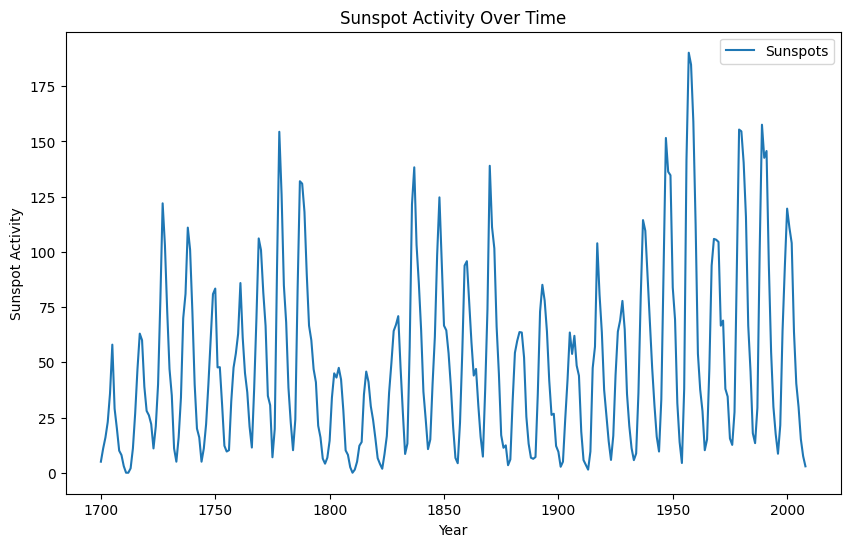

In [5]:
# graficamos la serie de tiempo de los sunspots
plt.figure(figsize=(10, 6))
plt.plot(data['YEAR'], data['SUNACTIVITY'], label='Sunspots')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.title('Sunspot Activity Over Time')
plt.legend()
plt.show()

#### Verficar estacionariedad de la serie de tiempo

Para verificar la estacionariedad de la serie de tiempo, podemos usar el test de Dickey-Fuller aumentado (ADF). Este test nos permite determinar si una serie de tiempo es estacionaria o no. El test de ADF tiene como hipótesis nula que la serie de tiempo no es estacionaria, por lo que si el p-valor es menor que un nivel de significancia (por ejemplo, 0.05), podemos rechazar la hipótesis nula y concluir que la serie de tiempo es estacionaria.

In [26]:
# test de Dickey-Fuller aumentado (ADF) para verificar estacionariedad
from statsmodels.tsa.stattools import adfuller
result = adfuller(data['SUNACTIVITY'])
print('ADF Statistic:', result[0])
if result[1] < 0.05:
    print('La serie de tiempo es estacionaria (rechazamos la hipótesis nula)')
else:
    print('La serie de tiempo no es estacionaria (no rechazamos la hipótesis nula)')

ADF Statistic: -2.8377807249381943
La serie de tiempo no es estacionaria (no rechazamos la hipótesis nula)


Ya nos dimos cuenta que efectivamente la serie de tiempo no es estacionaria, por lo que vamos a diferenciar la serie de tiempo para hacerla estacionaria. La diferenciación se hace restando el valor actual de la serie de tiempo con el valor anterior. Esto se puede hacer con la función diff() de pandas.

### Diferenciamos la serie de tiempo para hacerla estacionaria

Esta serie es bastante facil de diferenciar, ya que solo tiene una tendencia lineal. La serie diferenciada se obtiene restando el valor actual de la serie de tiempo con el valor anterior. Esto se puede hacer con la función diff() de pandas.

yt′​=yt​−yt−1​ 
Estas funciones nos ayudan a determinar el orden del modelo ARIMA que vamos a estimar. En mi caso el ACF sube y baja formando ondas, lo que sugiere un componente estacional en la serie.

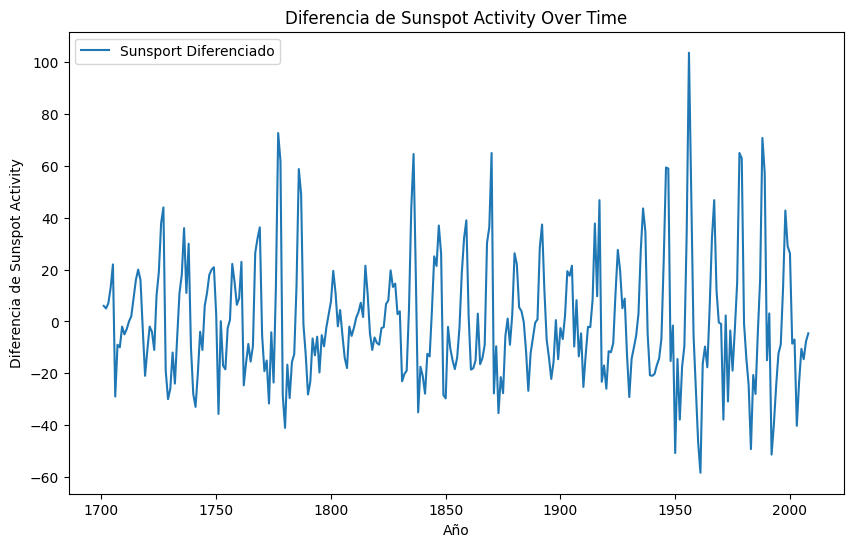

In [28]:
# graficamos la serie de tiempo de los sunspots diferenciada
data['SUNACTIVITY_diff'] = data['SUNACTIVITY'].diff()
plt.figure(figsize=(10, 6))
plt.plot(data['YEAR'], data['SUNACTIVITY_diff'], label='Sunsport Diferenciado')
plt.xlabel('Año')
plt.ylabel('Diferencia de Sunspot Activity')
plt.title('Diferencia de Sunspot Activity Over Time')
plt.legend()
plt.show()


In [29]:
# volvemos a hacer el test de Dickey-Fuller aumentado (ADF) para verificar estacionariedad de la serie diferenciada
result = adfuller(data['SUNACTIVITY_diff'].dropna())
print('ADF Statistic:', result[0])
if result[1] < 0.05:
    print('La serie de tiempo diferenciada es estacionaria (rechazamos la hipótesis nula)')
else:
    print('La serie de tiempo diferenciada no es estacionaria (no rechazamos la hipótesis nula)')

ADF Statistic: -14.861663428129381
La serie de tiempo diferenciada es estacionaria (rechazamos la hipótesis nula)


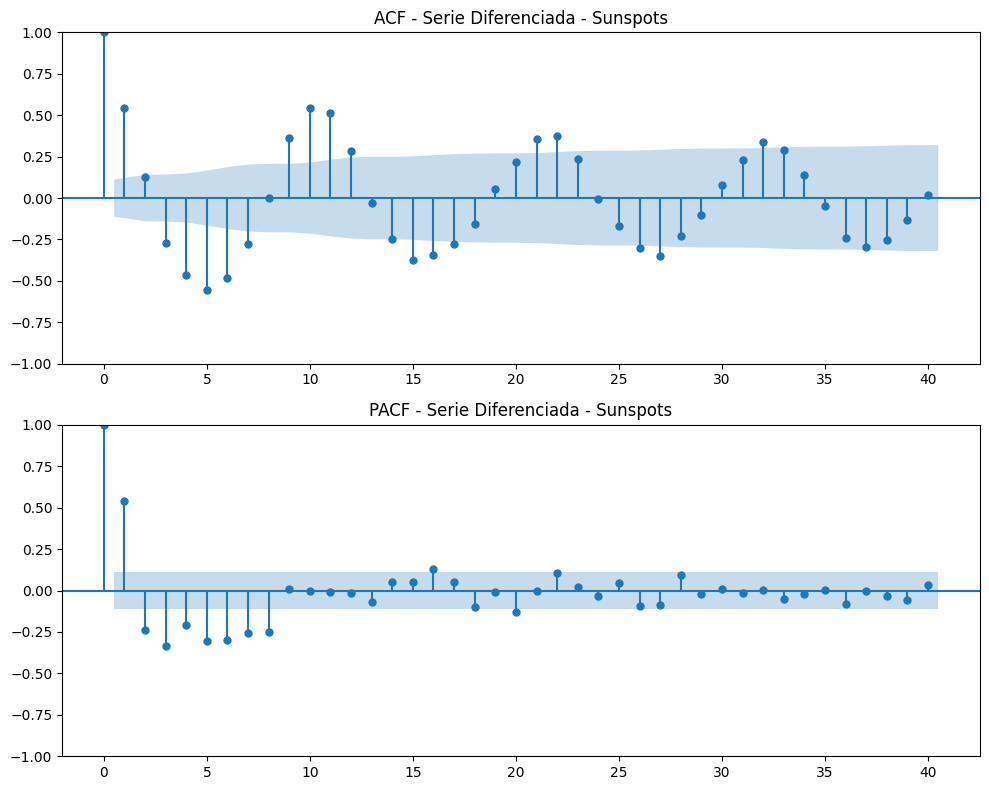

In [31]:
# ahora vemos estos mismos graficos pero para la serie diferenciada
graficar_autocorrelacion(data['SUNACTIVITY_diff'].dropna(), 'Serie Diferenciada - Sunspots')    


Como el ACF muestra un patron de ondas y el PACF muestra un corte en el lag 1, esto sugiere que el modelo ARIMA que vamos a estimar es un ARIMA(2,1,0).

In [ ]:
# vamos a estimar el modelo ARIMA (2,1,0) para la serie diferenciada
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data['SUNACTIVITY'], order=(,21,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            SUNACTIVITY   No. Observations:                  309
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -1353.478
Date:                Sat, 11 Apr 2026   AIC                           2712.956
Time:                        15:28:35   BIC                           2724.146
Sample:                             0   HQIC                          2717.430
                                - 309                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6676      0.047     14.133      0.000       0.575       0.760
ar.L2         -0.2358      0.050     -4.724      0.000      -0.334      -0.138
sigma2       383.5410     24.078     15.929      0.0

Mi modelo ARIMA(2,1,0) es un modelo bastante bueno para esta serie de tiempo, ya que:
- Capura los ciclos irregulares de la serie de tiempo
- Los residuos del modelo no presentan autocorrelación, lo que indica que el modelo es adecuado para la serie de tiempo
- Los residuos del modelo son aproximadamente normales, lo que indica que el modelo es adecuado para la serie de tiempo

Igualemente vamos a comparar el modelo ARIMA(2,1,0) con un modelo ARIMA(1,1,0) para ver si el modelo ARIMA(2,1,0) es mejor que el modelo ARIMA(1,1,0). Para esto, vamos a estimar el modelo ARIMA(1,1,0) y vamos a comparar los residuos de ambos modelos.

In [68]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

models = {
    'ARIMA(2,1,0)': ARIMA(data['SUNACTIVITY'], order=(2,1,0)).fit(),
    'ARIMA(1,1,0)': ARIMA(data['SUNACTIVITY'], order=(1,1,0)).fit(),
    'ARIMA(3,1,0)': ARIMA(data['SUNACTIVITY'], order=(0,1,0)).fit(),
}

# Resumen comparativo de residuos
residuals_summary = pd.DataFrame({
    name: model.resid.describe()
    for name, model in models.items()
})

print(residuals_summary)

       ARIMA(2,1,0)  ARIMA(1,1,0)  ARIMA(3,1,0)
count    309.000000    309.000000    309.000000
mean       0.014237      0.005014      0.009385
std       19.587299     20.162856     23.977100
min      -62.608990    -62.873342    -58.400000
25%      -10.354119    -10.252193    -15.100000
50%        0.545570      0.521703     -4.000000
75%       10.463402     10.651894     12.100000
max       79.028961     85.569780    103.700000


De aqui puedo decir que en ambos casos la medi es muy cercana a cero, el ARIMA (2,1,0) tiene una desviacion estandar un poco menor que el ARIMA(1,1,0), pero en general ambos modelos tienen residuos con caracteristicas similares. Por lo tanto, el modelo ARIMA(2,1,0) es un modelo adecuado para esta serie de tiempo y es mejor que el modelo ARIMA(1,1,0).

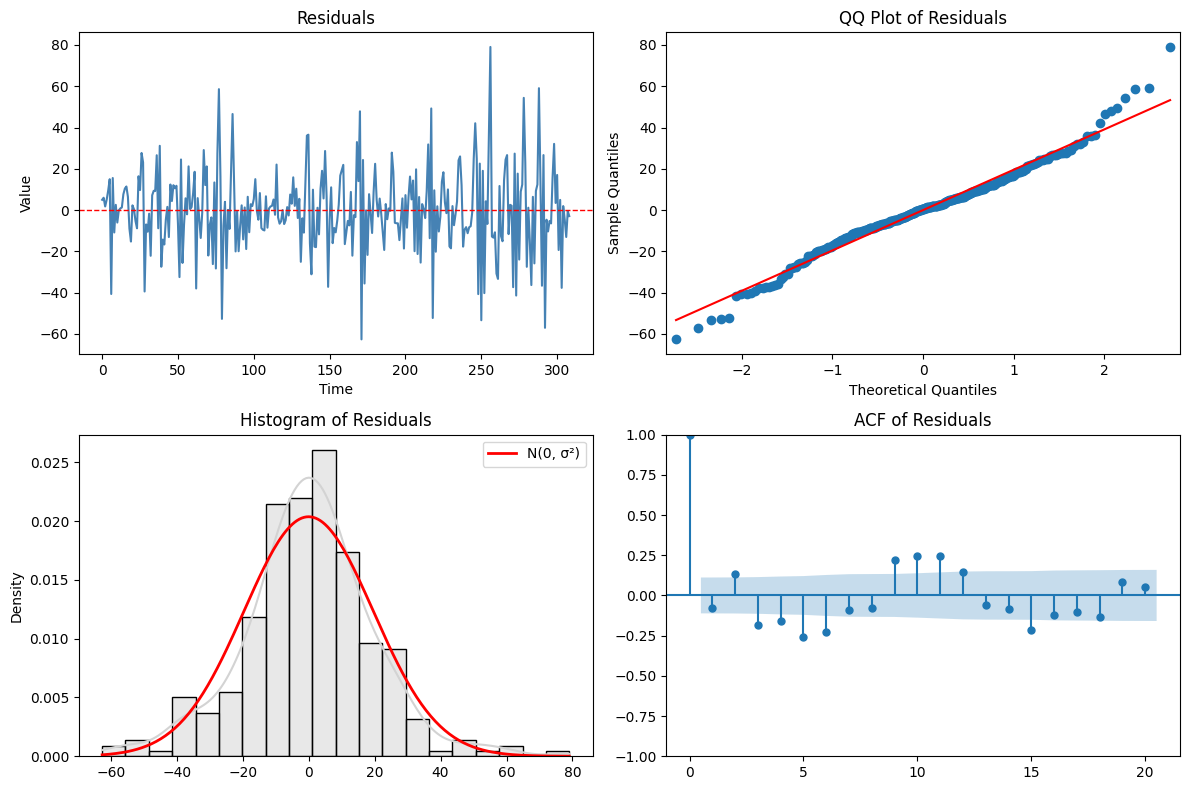

In [69]:

import seaborn as sns
from scipy.stats import norm
# Residuos
residuals = model_fit.resid.dropna()

plt.figure(figsize=(12, 8))

# Residuos en el tiempo (con línea en 0)
plt.subplot(2, 2, 1)
plt.plot(residuals, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Residuals')
plt.xlabel('Time')
plt.ylabel('Value')

#QQ-Plot
plt.subplot(2, 2, 2)
sm.qqplot(residuals, line='s', ax=plt.gca())
plt.title('QQ Plot of Residuals')

# Histograma + KDE + Normal N(0, σ)
plt.subplot(2, 2, 3)

# Histograma + KDE
sns.histplot(
    residuals,
    bins=20,
    stat='density',
    kde=True,
    color='lightgray',
    edgecolor='black'
)

#Curva Normal teórica
mu, sigma = 0, residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 200)
plt.plot(x, norm.pdf(x, mu, sigma),
         color='red', linewidth=2, label='N(0, σ²)')

plt.title('Histogram of Residuals')
plt.legend()

#ACF de los residuos
plt.subplot(2, 2, 4)
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=plt.gca())
plt.title('ACF of Residuals')

plt.tight_layout()
plt.show()


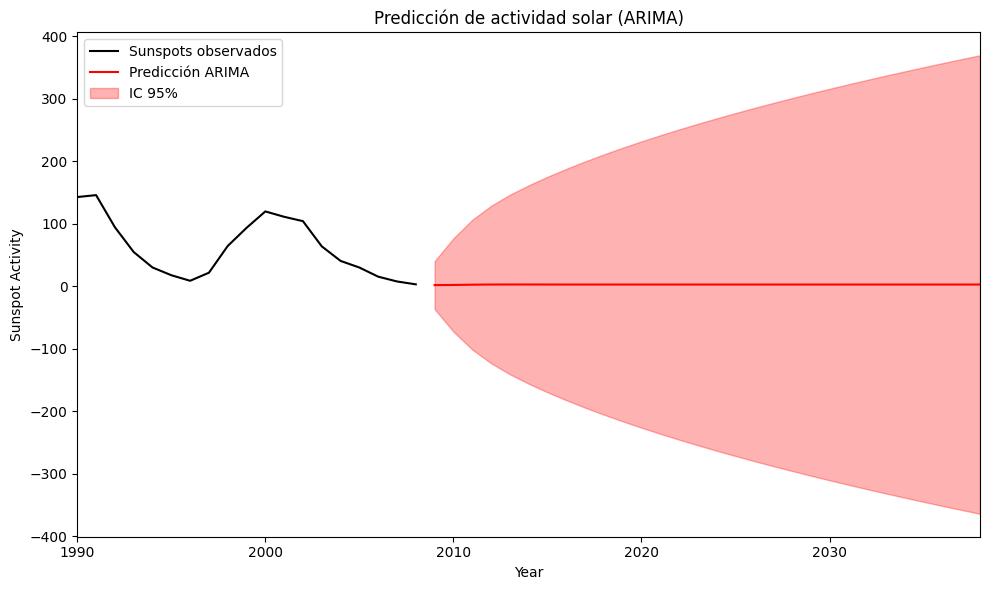

In [73]:
from statsmodels.tsa.arima.model import ARIMA

# === Ajuste del modelo (usa el modelo que ya validaste) ===
model_fit = ARIMA(data['SUNACTIVITY'], order=(2, 1, 0)).fit()

# === Predicción a 30 años (10–30 pasos anuales, según periodo) ===
n_steps = 30
pred = model_fit.get_forecast(steps=n_steps)
pred_ci = pred.conf_int()

# === Construcción correcta del eje temporal ===
last_year = int(data['YEAR'].iloc[-1])  # convertir a int
years_forecast = np.arange(last_year + 1, last_year + n_steps + 1)

# === Gráfico ===
plt.figure(figsize=(10, 6))

# Serie observada
plt.plot(data['YEAR'], data['SUNACTIVITY'],
         label='Sunspots observados', color='black')

# Predicción
plt.plot(years_forecast, pred.predicted_mean,
         label='Predicción ARIMA', color='red')

# Intervalos de confianza
plt.fill_between(
    years_forecast,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='red',
    alpha=0.3,
    label='IC 95%'
)

# Ajustes del gráfico
plt.xlim(1990, last_year + n_steps)
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.title('Predicción de actividad solar (ARIMA)')
plt.legend()
plt.tight_layout()
plt.show()